# ABEL Ptarmigan strong-field QED tracking example

By Carl A. Lindstrøm (University of Oslo), 8 Oct 2026

### Import ABEL framework

In [1]:
from abel import *

### Define the beam and SFQED interaction point

In [2]:
# define beam
source = SourceBasic()
source.charge = -1e10 * SI.e # [C]
source.energy = 30e9 # [eV]
source.rel_energy_spread = 0.01
source.bunch_length = 18e-6 # [m]
source.z_offset = 10e-6 # [m]
source.emit_nx, source.emit_ny = 10e-6, 10e-6 # [m rad]
source.beta_x = 0.01
source.beta_y = source.beta_x
source.num_particles = 10000

# define SFQED interaction
target_sfqed = TargetSFQEDPtarmigan()
#target_sfqed = TargetSFQEDBasic()
target_sfqed.laser_a0 = 5.0
target_sfqed.laser_waist_radius = 3e-6
target_sfqed.laser_duration_fwhm = 10e-15
target_sfqed.collision_angle_deg = 0.0
target_sfqed.enable_pair_creation = True
target_sfqed.enable_radiation_reaction = True
target_sfqed.increase_pair_rate_by = 1000

# set up a linac
linac = PlasmaLinac()
linac.source = source
linac.target = target_sfqed

In [3]:
# show the laser parameters
linac.target.print_laser_parameters()

Laser parameters:
> Wavelength:   800 nm
> a0:           5.0
> Duration:     10 fs FWHM
> Waist radius: 3.0 µm
------------------------------
> Intensity:    5.3e+19 W/cm^2
> Peak power:   0.01 PW
> Energy:       0.09 J


### Run simulations

In [4]:
linac.run('sfqed_example', num_shots=1, overwrite=True)

Tracked #0  SourceBasic                 (s =    0.0 m) :   E =  30.0 GeV, Q = -1.60 nC, σz =  17.9 µm, σE =  1.0%, ε =  10.1/10.11 mm-mrad
Finished Ptarmigan: 100%|██████████████████████████████████████████| 10000/10000 [00:09<00:00, 1106.49 particles/s]
    ... #1  TargetSFQEDPtarmigan        (s =    0.0 m) :   E =  27.3 GeV, Q = -1.60 nC, σz =  17.9 µm, σE = 18.6%, ε =   9.3/9.39 mm-mrad


### Show the outputs

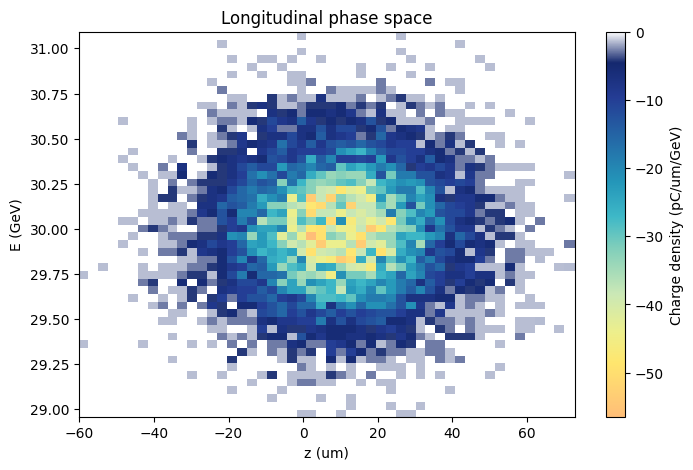

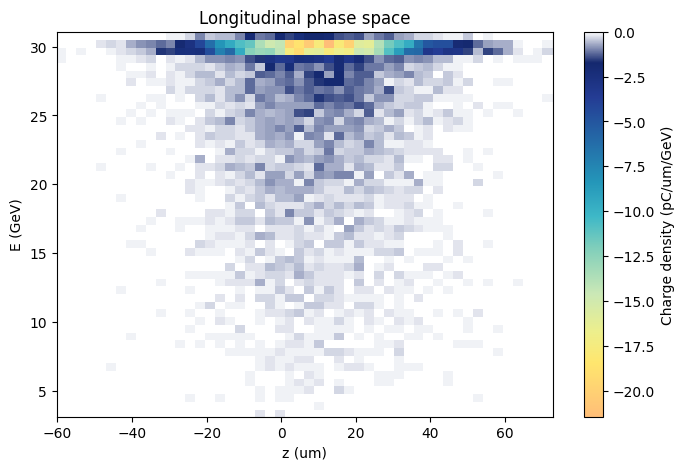

In [5]:
# plot the longitudinal phase space before and after interaction
linac.initial_beam.plot_lps()
linac.final_beam.plot_lps()

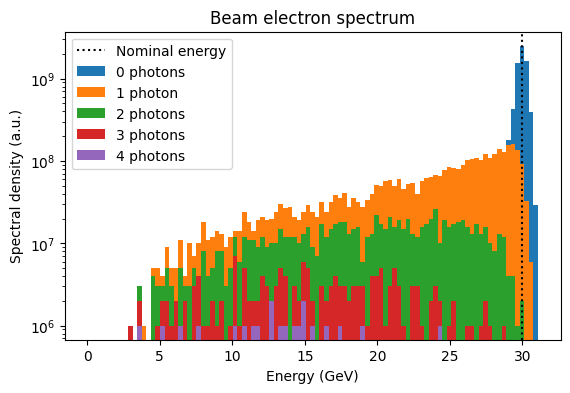

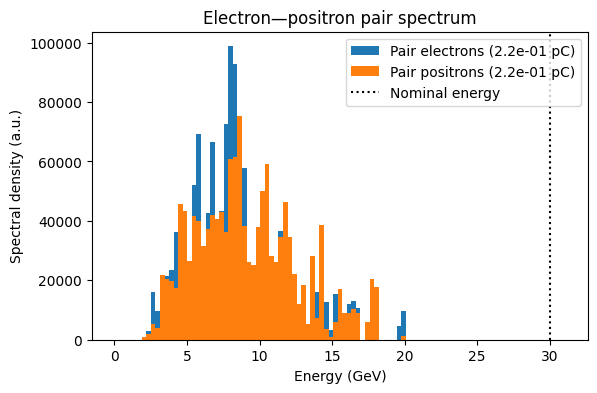

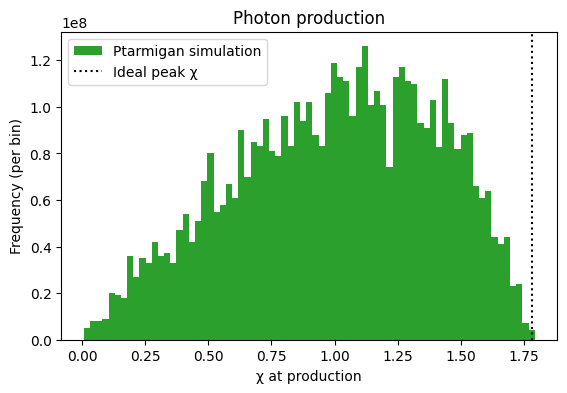

In [6]:
# show the outputs
linac.target.plot_beam_spectrum(log_plot=True)
linac.target.plot_pair_spectrum()
linac.target.plot_photon_chis()

### Scan example

In [7]:
# scan the a0
linac.target.enable_pair_creation = False # if only looking at effects on the beam
linac.scan('sfqed_example_a0_scan', 
           lambda obj, val: setattr(obj.target, 'laser_a0', val) or obj, 
           np.logspace(np.log10(0.4), np.log10(40), 64),
           label='a0',
           num_shots_per_step=1, 
           parallel=True,
           overwrite=True);

Output()

/Users/carlal/UiO/Code/software/ABEL/src/abel/classes/runnable.py:518: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


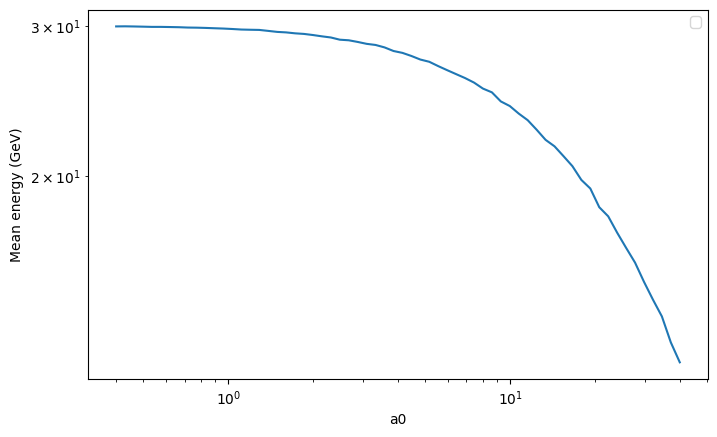

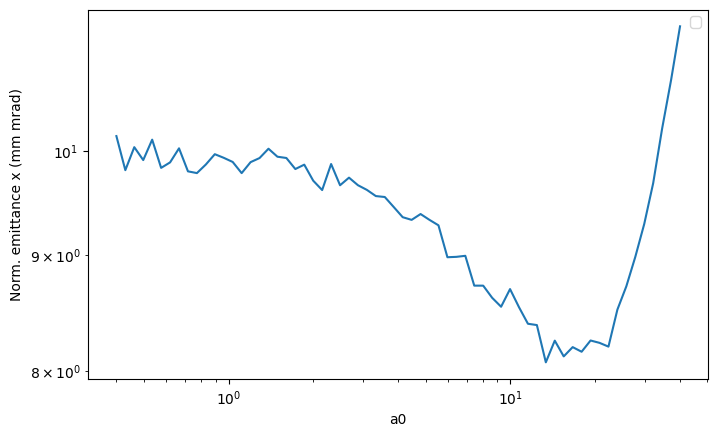

In [8]:
linac.plot_beam_function(Beam.energy, scale=1e9, label='Mean energy (GeV)', xscale='log', yscale='log')
linac.plot_beam_function(Beam.norm_emittance_x, scale=1e-6, label='Norm. emittance x (mm mrad)', xscale='log', yscale='log')